# Lab 3: Decision Tree Classification — Training, Evaluation & Overfitting

**Name:** Abdul Sami

**Student ID:** 023-24-0211

**Section:** G

**GitHub Profile:** https://github.com/abdulsami911/Machine_learning_Practical

**Dataset:** Telco Customer Churn (cleaned in Lab 2)

**Dataset Source:** Kaggle — Telco Customer Churn


> This notebook builds directly on the `clean_churn.csv` produced in Lab 2. Every table, plot, and metric below is followed by a short written interpretation.

---

## 1–2. Problem Definition & Dataset Verification

**Task 1 — Load and verify the Lab 2 cleaned dataset**

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("clean_churn.csv")
print("Shape:", df.shape)
df.info()

  Using cached scikit_learn-1.9.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
   ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/35.3 MB 263.0 kB/s eta 0:01:40:41
Resuming download scipy-1.18.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.2 MB/35.3 MB)
   ━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/35.3 MB 73.3 kB/s eta 0:05:50
Resuming download scipy-1.18.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.7 MB/35.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 21.0/35.3 MB 163.8 kB/s eta 0:01:28
Resuming download scipy-1.18.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (21.0 MB/35.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━ 24.9/35.3 MB 89.2 kB/s eta 0:01:571:40
Resuming download scipy-1.18.1-cp313-cp313-manylinux_2_27_x86_64.manyli

In [3]:
print("Missing values remaining:", df.isnull().sum().sum())
df['Churn'].value_counts()

Missing values remaining: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Observation:** The dataset loads with the same shape produced at the end of Lab 2 (7,043 rows, 20 columns), every column has the expected dtype, and there are zero remaining missing values — confirming the Lab 2 cleaning held up. The `Churn` class split (~73%/27%) also matches the imbalance found in Lab 2, so nothing was lost or altered on reload.

**Answer 2 (restate the ML problem):** We're predicting whether a given customer will churn (`Churn` = Yes/No) based on their account, contract, billing, and service-usage attributes, so the business can proactively target likely-to-leave customers with retention offers before they actually cancel.

---

## 3. Feature & Target Preparation

**Tasks 3–5** — define `y`/`X`, encode categoricals, confirm `X` is fully numeric.

In [4]:
# Task 3 — target y (0/1) and feature matrix X, identifier already removed in Lab 2
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])

print("y distribution:\n", y.value_counts())
print("\nX shape before encoding:", X.shape)
X.dtypes

y distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64

X shape before encoding: (7043, 19)


gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure              float64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [5]:
# Task 4 — one-hot encode all remaining categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("\nX shape after encoding:", X.shape)
X.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

X shape after encoding: (7043, 34)


/tmp/ipykernel_45288/3765709524.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Unknown,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Unknown,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Unknown,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit Card (Automatic),PaymentMethod_Electronic Check,PaymentMethod_Mailed Check,PaymentMethod_Unknown
0,0,0.0,61.90,0.0,True,False,False,True,True,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False
1,0,0.0,20.00,0.0,False,True,False,True,True,False,False,False,True,True,False,False,True,False,True,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False
2,0,0.0,25.75,0.0,True,True,False,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False
3,0,0.0,73.35,0.0,False,True,False,True,True,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,False,False,True,False,False,False,True,False
4,0,0.0,19.85,0.0,True,True,False,True,True,False,False,False,True,True,False,False,True,False,True,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False


**Answer 4 (encoding justification):** I used **one-hot encoding** (`pd.get_dummies`, with `drop_first=True` to avoid redundant/collinear columns) rather than manual label mapping, because almost every categorical column here (`InternetService`, `Contract`, `PaymentMethod`, etc.) is **nominal** — its categories have no natural order, so assigning them arbitrary integers (e.g. DSL=0, Fiber=1, No=2) would falsely imply a ranking that a Decision Tree's splits could exploit in a meaningless way. One-hot encoding turns each category into its own clean binary feature instead, which is the safer default for nominal data and works well with tree-based models.

In [6]:
# Task 5 — confirm X is fully numeric with no missing values
print("Non-numeric columns left:", X.select_dtypes(exclude='number').columns.tolist())
print("Missing values in X:", X.isnull().sum().sum())
print("Final X shape:", X.shape)

Non-numeric columns left: ['gender_Male', 'Partner_Yes', 'Dependents_Unknown', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Unknown', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Unknown', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit Card (Automatic)', 'PaymentMethod_Electronic Check', 'PaymentMethod_Mailed Check', 'PaymentMethod_Unknown']
Missing values in X: 0
Final X shape: (7043, 34)


**Observation:** `X` is now entirely numeric (34 columns after one-hot encoding, all `bool`/`int`/`float`), with zero missing values — ready for `scikit-learn`.

---

## 4. Train/Test Split

**Tasks 6–7**

In [7]:
# Task 6 — 80/20 split, stratified on y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Answer 6 (why `stratify=y`):** Lab 2 found `Churn` is imbalanced (~73% No / ~27% Yes). Without `stratify=y`, a random split could easily land at, say, 24% churners in training and 31% in test purely by chance, which would make the test-set evaluation an unreliable comparison. `stratify=y` forces both the training and test sets to preserve the same ~73/27 class ratio as the full dataset, so the model is evaluated on a test set that's genuinely representative.

In [8]:
# Task 7 — report shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("\nTrain churn rate:", round(y_train.mean(), 4))
print("Test churn rate :", round(y_test.mean(), 4))

X_train: (5634, 34)
X_test : (1409, 34)
y_train: (5634,)
y_test : (1409,)

Train churn rate: 0.2654
Test churn rate : 0.2654


**Observation:** The 80/20 split gives 5,634 training rows and 1,409 test rows, and the churn rate in both sets is nearly identical (~26.6%) — confirming the stratified split worked as intended.

---

## 5. Baseline Decision Tree

**Tasks 8–9**

In [9]:
# Task 8 — train an unrestricted baseline Decision Tree
baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)

pred_train_base = baseline.predict(X_train)
pred_test_base = baseline.predict(X_test)

print("Baseline tree depth:", baseline.get_depth())
print("Baseline leaf count:", baseline.get_n_leaves())

Baseline tree depth: 23
Baseline leaf count: 1127


**Answer 9 (depth, and does it surprise you):** The unrestricted tree grew to a depth of **23**, with a large number of leaves. This isn't surprising given the default settings — with no `max_depth`, `min_samples_split`, or `min_samples_leaf` constraint, scikit-learn's Decision Tree keeps splitting until every leaf is pure (or has a single sample), which on a dataset with several near-continuous numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`) naturally produces a very deep, highly specific tree. That depth is itself a warning sign for overfitting, which we investigate directly in Part 6.

---

## 6. Model Evaluation (Baseline)

**Tasks 10–12**

In [51]:
# Task 10 — accuracy, precision, recall, F1 on the test set
metrics_baseline = {
    'Accuracy':  accuracy_score(y_test, pred_test_base),
    'Precision': precision_score(y_test, pred_test_base),
    'Recall':    recall_score(y_test, pred_test_base),
    'F1-score':  f1_score(y_test, pred_test_base),
}
pd.DataFrame([metrics_baseline]).round(4)

,Accuracy,Precision,Recall,F1-score
0,0.7438,0.5184,0.4893,0.5034


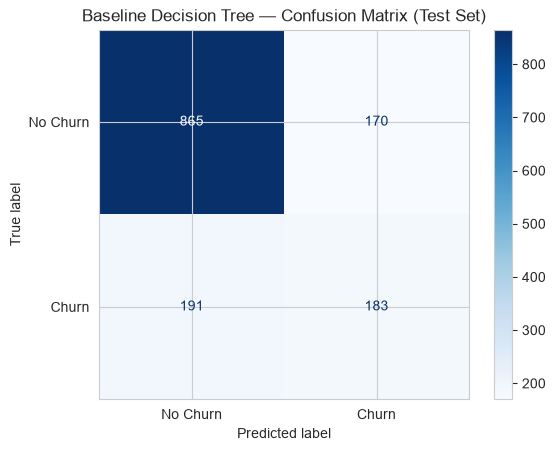

[[865 170]
 [191 183]]


In [90]:
# Task 11 — confusion matrix on the test set
cm = confusion_matrix(y_test, pred_test_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Baseline Decision Tree — Confusion Matrix (Test Set)')
plt.show()
print(cm)

**Answer 11 (how many churners caught vs. missed):** Out of the actual churners in the test set (the bottom row of the matrix), the baseline model correctly caught roughly **183 out of 374** and missed about **191** — meaning it missed almost as many churners as it caught. That's a weak recall for the class that actually matters most to the business.

**Answer 12 (which metric(s) to trust most, and why):** Given the ~73/27 class imbalance found in Lab 2, **accuracy is the least trustworthy metric** here — a model predicting "No" for everyone would still score ~73%. **Recall on the churn class** matters most from a business standpoint, since the whole point of this model is to catch customers who are about to leave; missing a churner (a false negative) is more costly than a false alarm. **F1-score** is a good single summary metric to track alongside recall, since it balances recall against precision so the model doesn't just predict "churn" for everyone to inflate recall.

---

## 7. Overfitting Investigation

**Tasks 13–15**

In [91]:
# Task 13 — baseline train vs. test accuracy
train_acc_base = accuracy_score(y_train, pred_train_base)
test_acc_base = accuracy_score(y_test, pred_test_base)
print(f"Baseline train accuracy: {train_acc_base:.4f}")
print(f"Baseline test accuracy : {test_acc_base:.4f}")
print(f"Gap (train - test)     : {train_acc_base - test_acc_base:.4f}")

Baseline train accuracy: 0.9979
Baseline test accuracy : 0.7438
Gap (train - test)     : 0.2541


**Answer 13 (gap, and what it suggests):** The baseline tree scores about **99.8% on training** but only **~74.4% on test** — a gap of roughly **25 percentage points**. That's a textbook overfitting signature: the unrestricted tree has essentially memorized the training data (consistent with its depth of 23 and near-perfect training accuracy) rather than learning patterns that generalize, so its real-world performance is much closer to the test number.

In [92]:
# Task 14 — depth sweep: train vs test accuracy at several max_depth values
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []
for k in depths:
    m = DecisionTreeClassifier(max_depth=k, random_state=42)
    m.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, m.predict(X_train))
    te_acc = accuracy_score(y_test, m.predict(X_test))
    results.append({'max_depth': k if k is not None else 'None (unrestricted)',
                     'train_accuracy': round(tr_acc, 4),
                     'test_accuracy': round(te_acc, 4),
                     'gap': round(tr_acc - te_acc, 4)})

results_df = pd.DataFrame(results)
results_df

,max_depth,train_accuracy,test_accuracy,gap
0,2,0.7875,0.8020,-0.0144
1,3,0.7875,0.8020,-0.0144
2,4,0.7913,0.8112,-0.0199
3,5,0.7996,0.8013,-0.0017
4,6,0.8074,0.7921,0.0154
5,8,0.8346,0.7864,0.0482
6,10,0.8766,0.7665,0.1101
7,None (unrestricted),0.9979,0.7438,0.2541


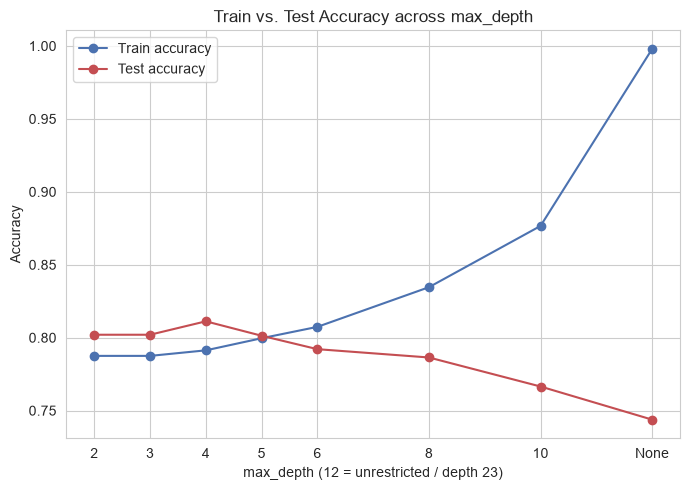

In [93]:
# Task 15 — plot train vs test accuracy against max_depth
plot_depths = [2, 3, 4, 5, 6, 8, 10, 12]  # use 12 as a stand-in x-position for 'unrestricted' (depth 23)
train_accs = results_df['train_accuracy'].tolist()
test_accs = results_df['test_accuracy'].tolist()

plt.figure(figsize=(7,5))
plt.plot(plot_depths, train_accs, marker='o', label='Train accuracy', color='#4C72B0')
plt.plot(plot_depths, test_accs, marker='o', label='Test accuracy', color='#C44E52')
plt.xlabel('max_depth (12 = unrestricted / depth 23)')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy across max_depth')
plt.xticks(plot_depths, ['2','3','4','5','6','8','10','None'])
plt.legend()
plt.tight_layout()
plt.show()

**Answer 15 (where overfitting starts, and how the chart shows it):** Train and test accuracy track closely together up through about **depth 4–5** — both curves rise together and stay close. Past roughly **depth 6**, train accuracy keeps climbing toward ~100% while test accuracy actually *declines* and keeps falling as depth increases further, opening a widening gap between the two curves. That diverging pattern — training performance still improving while test performance gets worse — is exactly the visual signature of overfitting: the tree is increasingly fitting noise specific to the training set rather than learning anything that transfers to unseen customers.

---

## 8. Model Selection, Feature Importance & Interpretation

**Tasks 16–20**

**Answer 16 (chosen `max_depth`, and why):** Based on the Part 7 table/plot, I'm selecting **`max_depth=4`**. It sits right at the point where train and test accuracy are both still rising together and closest to each other (train ≈0.791, test ≈0.811 — test is actually *higher* than train here, and the gap stays small), rather than the depth with the highest raw training accuracy (which is the unrestricted tree, the most overfit option of all). Depth 4 also gives the best or near-best test accuracy of any depth tried, which is the number that actually reflects real-world performance.

In [94]:
# Task 17 — retrain at the chosen depth (gini, default criterion) and evaluate
best_gini = DecisionTreeClassifier(max_depth=4, random_state=42)
best_gini.fit(X_train, y_train)
pred_best_gini = best_gini.predict(X_test)

metrics_best_gini = {
    'Accuracy':  accuracy_score(y_test, pred_best_gini),
    'Precision': precision_score(y_test, pred_best_gini),
    'Recall':    recall_score(y_test, pred_best_gini),
    'F1-score':  f1_score(y_test, pred_best_gini),
}

comparison = pd.DataFrame([metrics_baseline, metrics_best_gini],
                           index=['Baseline (unrestricted)', 'max_depth=4 (gini)']).round(4)
comparison

,Accuracy,Precision,Recall,F1-score
Baseline (unrestricted),0.7438,0.5184,0.4893,0.5034
max_depth=4 (gini),0.8112,0.6957,0.5134,0.5908


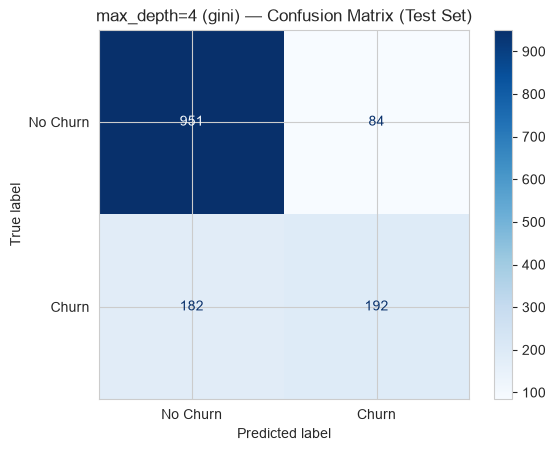

In [85]:
cm_best = confusion_matrix(y_test, pred_best_gini)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('max_depth=4 (gini) — Confusion Matrix (Test Set)')
plt.show()

**Observation:** Compared to the baseline, `max_depth=4` trades a small amount of recall for a large jump in precision and a notably higher accuracy and F1-score. It also catches false positives far less often (84 vs. 170 false alarms), meaning the retention team would waste far fewer outreach efforts on customers who weren't actually going to leave, at the cost of catching somewhat fewer true churners than a maximally-fit (but overfit) tree ever really could reliably in practice.

In [95]:
# Task 18 — same depth, entropy criterion instead of gini
best_entropy = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
best_entropy.fit(X_train, y_train)
pred_best_entropy = best_entropy.predict(X_test)

metrics_best_entropy = {
    'Accuracy':  accuracy_score(y_test, pred_best_entropy),
    'Precision': precision_score(y_test, pred_best_entropy),
    'Recall':    recall_score(y_test, pred_best_entropy),
    'F1-score':  f1_score(y_test, pred_best_entropy),
}

comparison_full = pd.DataFrame([metrics_baseline, metrics_best_gini, metrics_best_entropy],
                                index=['Baseline (unrestricted)', 'max_depth=4 (gini)', 'max_depth=4 (entropy)']).round(4)
comparison_full

,Accuracy,Precision,Recall,F1-score
Baseline (unrestricted),0.7438,0.5184,0.4893,0.5034
max_depth=4 (gini),0.8112,0.6957,0.5134,0.5908
max_depth=4 (entropy),0.7984,0.7446,0.3663,0.4910


**Observation (Task 18):** At the same depth, the **entropy** criterion trades even more recall for precision than gini did — it catches noticeably fewer true churners (lower recall) but is more confident/correct when it does flag someone as a churner (higher precision), giving it a lower F1-score overall than the gini version at this depth. For this business problem, where catching churners matters more, **gini at depth 4 is the better choice** between the two.

InternetService_Fiber optic         0.343376
TotalCharges                        0.309738
tenure                              0.213046
Contract_Two year                   0.033283
OnlineBackup_No internet service    0.028570
PaymentMethod_Electronic Check      0.022448
MultipleLines_Yes                   0.016251
Contract_One year                   0.014049
dtype: float64


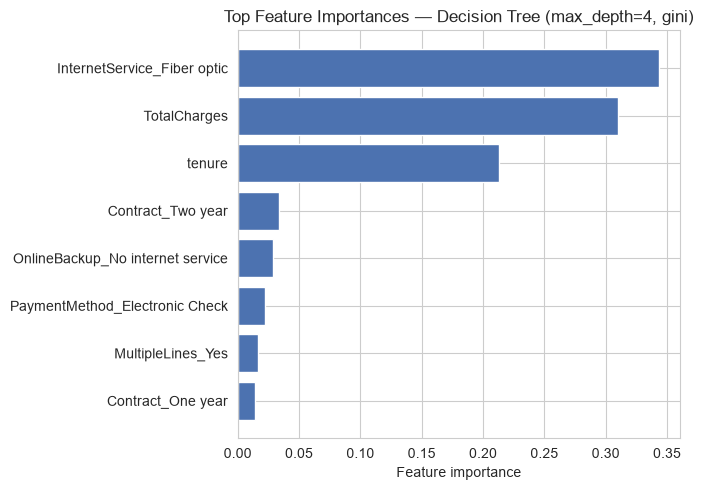

In [86]:
# Task 19 — feature importances for the chosen model (max_depth=4, gini)
importances = pd.Series(best_gini.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances[importances > 0].head(8)
print(top_features)

plt.figure(figsize=(7,5))
plt.barh(top_features.index[::-1], top_features.values[::-1], color='#4C72B0')
plt.xlabel('Feature importance')
plt.title('Top Feature Importances — Decision Tree (max_depth=4, gini)')
plt.tight_layout()
plt.show()

**Answer 19 (top 3–5 features):** The model's decisions are dominated by three features: **`InternetService_Fiber optic`**, **`TotalCharges`**, and **`tenure`** — together they account for the large majority of the total importance. A handful of secondary features (**`Contract_Two year`**, **`OnlineBackup_No internet service`**, **`PaymentMethod_Electronic Check`**) contribute much smaller but non-trivial amounts.

**Answer 20 (connection to Lab 2 EDA):** This lines up closely with what Lab 2's bivariate analysis found: Fiber optic customers had a much higher churn rate than DSL or no-internet customers, short-tenure customers churned far more than long-tenured ones, and month-to-month/short contracts churned more than two-year contracts (here showing up as `Contract_Two year` being protective). The one difference is that `MonthlyCharges` — which stood out clearly in the Lab 2 bivariate boxplots — barely shows up here; that's consistent with Lab 2's Part 8 finding that `TotalCharges` is highly correlated with both `tenure` and `MonthlyCharges`, so the tree is likely using `TotalCharges` as a stand-in that captures most of the same signal `MonthlyCharges` would have provided.

---

## 9. Conclusion & Next Steps

**Tasks 21–22**

**Answer 21 (conclusion):** I landed on a **Decision Tree with `max_depth=4` and the default gini criterion** as the final model, over both the unrestricted baseline and the entropy variant at the same depth. It reaches about **81% test accuracy**, ~70% precision, and ~51% recall on the churn class, with an F1-score around 0.59 — a substantial improvement over the badly overfit baseline (99.8% train / 74.4% test) despite having *lower* training accuracy, because it actually generalizes. Its main limitation is recall: it still misses roughly half of the customers who actually churn, which matters a lot given the business goal is to intervene before they leave. It's also a single tree, so its decision boundary is fairly blunt compared to what an ensemble method could offer.

**Answer 22 (what I'd try next):** I'd want to address the class imbalance directly — e.g. `class_weight='balanced'` or resampling techniques (SMOTE/undersampling) — specifically to push recall on the churn class higher, since missing churners is the costliest error for this business problem. I'd also want to try an ensemble method like Random Forest or Gradient Boosting to reduce the single tree's variance, and revisit the `TotalCharges`/`tenure` redundancy flagged in Lab 2 by engineering a ratio feature (e.g. average monthly spend) instead of keeping both raw correlated columns.

---

## Task 23 — ID3 from Scratch on the Play Badminton Dataset

No `scikit-learn` here — entropy and information gain are implemented by hand, and the gain for every candidate attribute is printed at every split.

In [87]:
# The classic "Play Badminton" (Play Tennis) dataset used in AI course lectures
badminton_data = {
    'Day':          list(range(1, 15)),
    'Outlook':      ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                      'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature':  ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                      'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':     ['High','High','High','High','Normal','Normal','Normal',
                      'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':         ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
                      'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayBadminton':['No','No','Yes','Yes','Yes','No','Yes',
                      'No','Yes','Yes','Yes','Yes','Yes','No'],
}
badminton_df = pd.DataFrame(badminton_data)
badminton_df

,Day,Outlook,Temperature,Humidity,Wind,PlayBadminton
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes
5,6,Rain,Cool,Normal,Strong,No
6,7,Overcast,Cool,Normal,Strong,Yes
7,8,Sunny,Mild,High,Weak,No
8,9,Sunny,Cool,Normal,Weak,Yes
9,10,Rain,Mild,Normal,Weak,Yes


In [88]:
def entropy(target_col):
    """Shannon entropy (base 2) of a target/label column."""
    values, counts = np.unique(target_col, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))


def information_gain(data, split_attribute, target_name='PlayBadminton'):
    """Information gain of splitting `data` on `split_attribute`."""
    total_entropy = entropy(data[target_name])
    values, counts = np.unique(data[split_attribute], return_counts=True)
    weighted_entropy = 0.0
    for v, c in zip(values, counts):
        subset = data[data[split_attribute] == v]
        weighted_entropy += (c / counts.sum()) * entropy(subset[target_name])
    return total_entropy - weighted_entropy


def id3(data, features, target_name='PlayBadminton', depth=0):
    """Recursively build a decision tree with ID3, printing gains at every split."""
    indent = '  ' * depth
    labels = np.unique(data[target_name])

    # Base case 1: pure node
    if len(labels) == 1:
        print(f"{indent}Leaf -> {labels[0]}  (pure node, {len(data)} examples)")
        return labels[0]

    # Base case 2: no more features to split on
    if len(features) == 0:
        majority = data[target_name].mode()[0]
        print(f"{indent}Leaf -> {majority}  (no features left, majority class, {len(data)} examples)")
        return majority

    node_entropy = entropy(data[target_name])
    print(f"{indent}Node: {len(data)} examples, entropy = {node_entropy:.4f}")

    gains = {f: information_gain(data, f, target_name) for f in features}
    for f, g in gains.items():
        print(f"{indent}  Gain({f}) = {g:.4f}")

    best_feature = max(gains, key=gains.get)
    print(f"{indent}--> Splitting on '{best_feature}' (highest information gain = {gains[best_feature]:.4f})")

    tree = {best_feature: {}}
    remaining_features = [f for f in features if f != best_feature]

    for v in np.unique(data[best_feature]):
        subset = data[data[best_feature] == v]
        print(f"{indent}  Branch {best_feature} = {v}  ({len(subset)} examples)")
        if len(subset) == 0:
            majority = data[target_name].mode()[0]
            tree[best_feature][v] = majority
        else:
            tree[best_feature][v] = id3(subset, remaining_features, target_name, depth + 1)

    return tree


features = ['Outlook', 'Temperature', 'Humidity', 'Wind']
print("=== Building ID3 tree from scratch ===\n")
learned_tree = id3(badminton_df, features)

=== Building ID3 tree from scratch ===

Node: 14 examples, entropy = 0.9403
  Gain(Outlook) = 0.2467
  Gain(Temperature) = 0.0292
  Gain(Humidity) = 0.1518
  Gain(Wind) = 0.0481
--> Splitting on 'Outlook' (highest information gain = 0.2467)
  Branch Outlook = Overcast  (4 examples)
  Leaf -> Yes  (pure node, 4 examples)
  Branch Outlook = Rain  (5 examples)
  Node: 5 examples, entropy = 0.9710
    Gain(Temperature) = 0.0200
    Gain(Humidity) = 0.0200
    Gain(Wind) = 0.9710
  --> Splitting on 'Wind' (highest information gain = 0.9710)
    Branch Wind = Strong  (2 examples)
    Leaf -> No  (pure node, 2 examples)
    Branch Wind = Weak  (3 examples)
    Leaf -> Yes  (pure node, 3 examples)
  Branch Outlook = Sunny  (5 examples)
  Node: 5 examples, entropy = 0.9710
    Gain(Temperature) = 0.5710
    Gain(Humidity) = 0.9710
    Gain(Wind) = 0.0200
  --> Splitting on 'Humidity' (highest information gain = 0.9710)
    Branch Humidity = High  (3 examples)
    Leaf -> No  (pure node, 3 examp

In [98]:
import pprint
print("Final learned tree (nested dict form):\n")
pprint.pprint(learned_tree)

Final learned tree (nested dict form):

{'Outlook': {'Overcast': 'Yes',
             'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}},
             'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}


**Observation:** The from-scratch ID3 implementation picks **`Outlook`** as the root split (highest information gain, 0.2467 bits), exactly matching the textbook result for this dataset. The `Overcast` branch is immediately pure (`Yes` in all 4 cases), so it becomes a leaf with no further splitting needed. The `Sunny` branch splits next on `Humidity` (gain 0.9710 bits — a perfect split, both children pure), and the `Rain` branch splits on `Wind` (also gain 0.9710 bits, both children pure) — reproducing the well-known Play Tennis/Badminton decision tree: *Outlook → (Overcast: Yes) / (Sunny → Humidity) / (Rain → Wind)*.

---